# Préparation des données

`01_eda.ipynb` a établi trois défauts de qualité et les décisions à prendre.
Ce notebook les applique — et surtout, **vérifie qu'elles servent à quelque
chose**. Une transformation qui n'améliore rien est une complexité gratuite :
elle alourdit le code, multiplie les occasions de se tromper, et devra être
maintenue.

| Constat | Décision |
|---|---|
| Codes 96/98 sur 269 lignes (54,6 % de défaut) | Passer en `NaN` **et** créer une indicatrice |
| Revenu absent sur 19,8 % des lignes, lié au défaut | Imputer **et** créer une indicatrice |
| `DebtRatio` mélange ratio et montant brut | Isoler les lignes sans ratio calculable |
| Âge à 0, utilisation du crédit jusqu'à 50 708 | Écrêter et signaler |

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..").resolve()))
from src.preparation import NettoyageCredit, charger_donnees

warnings.filterwarnings("ignore", category=FutureWarning)

DATA = Path("../data/raw")
HASARD = 0

## 1. Séparer avant de toucher à quoi que ce soit

L'ordre des opérations n'est pas un détail de présentation. Toute quantité
apprise sur les données — une médiane d'imputation, un plafond d'écrêtage, une
moyenne de normalisation — doit être calculée **sur le seul jeu
d'entraînement**, puis appliquée telle quelle à la validation.

Calculer une médiane sur l'ensemble des lignes puis découper revient à laisser
filtrer de l'information du jeu de validation vers l'entraînement. Le score
monte, le modèle ne s'améliore pas, et la déconvenue arrive en production.
C'est la fuite de données la plus banale, et elle passe inaperçue parce qu'elle
n'affiche aucune erreur.

On sépare donc en premier, et on n'y revient plus.

In [2]:
X, y = charger_donnees(DATA / "cs-training.csv")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=HASARD
)

print(f"Entraînement : {len(X_train):>7,} dossiers, {y_train.mean():.2%} de défauts".replace(",", " "))
print(f"Validation   : {len(X_val):>7,} dossiers, {y_val.mean():.2%} de défauts".replace(",", " "))

Entraînement : 105 000 dossiers  6.68% de défauts
Validation   :  45 000 dossiers  6.68% de défauts


`stratify=y` garantit que les deux jeux contiennent la même proportion de
défauts. Sans cette précaution, avec une cible à 6,7 %, un tirage malheureux
suffirait à décaler sensiblement le taux entre les deux échantillons et à
rendre les scores incomparables.

## 2. Le nettoyage, sous forme de transformateur

Les décisions de l'exploration sont codées dans `src/preparation.py`, comme un
transformateur scikit-learn plutôt que comme une suite de manipulations dans
le notebook. Trois raisons :

- il s'insère dans un `Pipeline`, donc le nettoyage est réappris à chaque pli
  de validation croisée au lieu d'être appliqué une fois pour toutes ;
- il est testable et réutilisable par les notebooks suivants ;
- il rend la fuite de données structurellement impossible, puisque `fit` ne
  voit jamais la validation.

In [3]:
nettoyage = NettoyageCredit()
apercu = nettoyage.fit_transform(X_train)

nouvelles = [c for c in apercu.columns if c not in X_train.columns]
print(f"{X_train.shape[1]} colonnes en entrée -> {apercu.shape[1]} en sortie")
print(f"Indicatrices créées : {nouvelles}")
print()
apercu[nouvelles].sum().to_frame("dossiers concernés")

10 colonnes en entrée -> 13 en sortie
Indicatrices créées : ['code_saisie', 'ratio_non_calculable', 'utilisation_aberrante']



,dossiers concernés
code_saisie,186
ratio_non_calculable,21899
utilisation_aberrante,258


In [4]:
# Ce que le nettoyage a effacé : les valeurs impossibles deviennent des NaN,
# que l'imputation traitera ensuite de façon explicite.
comparaison = pd.DataFrame({
    "avant": [
        X_train["NumberOfTimes90DaysLate"].max(),
        X_train["RevolvingUtilizationOfUnsecuredLines"].max(),
        X_train["age"].min(),
        X_train["DebtRatio"].max(),
    ],
    "après": [
        apercu["NumberOfTimes90DaysLate"].max(),
        apercu["RevolvingUtilizationOfUnsecuredLines"].max(),
        apercu["age"].min(),
        apercu["DebtRatio"].max(),
    ],
}, index=["max incidents 90j", "max utilisation crédit", "âge minimum", "max DebtRatio"])
comparaison.round(2)

,avant,après
max incidents 90j,98.0,17.0
max utilisation crédit,50708.0,2.0
âge minimum,0.0,21.0
max DebtRatio,326442.0,61106.5


## 3. Deux familles de modèles, deux traitements

Le nettoyage ne rend pas le même service à tous les algorithmes, et c'est
attendu :

- La **régression logistique** ajuste un coefficient par variable. Une valeur à
  50 708 dans une colonne qui vaut 0,3 ailleurs déforme la pente pour tout le
  monde. Elle exige donc imputation, écrêtage et normalisation.
- **LightGBM** ne compare que des seuils de découpe. Une valeur extrême finit
  isolée dans une feuille, sans effet sur le reste. Il gère de plus les `NaN`
  nativement, en apprenant de quel côté de chaque découpe les envoyer — ce qui
  est souvent meilleur qu'une imputation par la médiane.

On ne donne donc pas d'imputation à LightGBM : ce serait lui retirer une
information qu'il sait exploiter.

In [5]:
def chaine_logistique(avec_nettoyage: bool) -> Pipeline:
    etapes = []
    if avec_nettoyage:
        etapes.append(("nettoyage", NettoyageCredit()))
    etapes += [
        # add_indicator conserve la trace des valeurs manquantes imputées :
        # sur ce jeu, leur absence est elle-même prédictive.
        ("imputation", SimpleImputer(strategy="median", add_indicator=True)),
        ("normalisation", StandardScaler()),
        ("modele", LogisticRegression(max_iter=2000)),
    ]
    return Pipeline(etapes)


def chaine_lightgbm(avec_nettoyage: bool) -> Pipeline:
    etapes = []
    if avec_nettoyage:
        etapes.append(("nettoyage", NettoyageCredit()))
    etapes.append(("modele", LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        random_state=HASARD, verbose=-1, n_jobs=4,
    )))
    return Pipeline(etapes)


chaines = {
    "logistique / brut": chaine_logistique(False),
    "logistique / nettoyé": chaine_logistique(True),
    "lightgbm / brut": chaine_lightgbm(False),
    "lightgbm / nettoyé": chaine_lightgbm(True),
}
chaines["logistique / nettoyé"]

Pipeline(steps=[('nettoyage', NettoyageCredit()),
                ('imputation',
                 SimpleImputer(add_indicator=True, strategy='median')),
                ('normalisation', StandardScaler()),
                ('modele', LogisticRegression(max_iter=2000))])

## 4. Le nettoyage améliore-t-il le résultat ?

On mesure chaque chaîne de deux façons. La **validation croisée à 5 plis sur
l'entraînement** donne une moyenne et un écart-type : sans cet écart-type,
impossible de dire si un écart de score est un progrès ou du bruit. Le **jeu
de validation**, jamais vu pendant l'ajustement, sert de contrôle final.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=HASARD)

resultats = []
for nom, chaine in chaines.items():
    scores = cross_val_score(chaine, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    chaine.fit(X_train, y_train)
    auc_val = roc_auc_score(y_val, chaine.predict_proba(X_val)[:, 1])
    resultats.append({
        "chaîne": nom,
        "AUC (CV)": scores.mean(),
        "écart-type": scores.std(),
        "AUC (validation)": auc_val,
    })
    print(f"{nom:<22} terminé")

resultats = pd.DataFrame(resultats).set_index("chaîne")
resultats.round(4)

logistique / brut      terminé


logistique / nettoyé   terminé


lightgbm / brut        terminé


lightgbm / nettoyé     terminé


,AUC (CV),écart-type,AUC (validation)
chaîne,,,
logistique / brut,0.6980,0.0070,0.6994
logistique / nettoyé,0.8506,0.0036,0.8524
lightgbm / brut,0.8615,0.0028,0.8655
lightgbm / nettoyé,0.8609,0.0028,0.8648


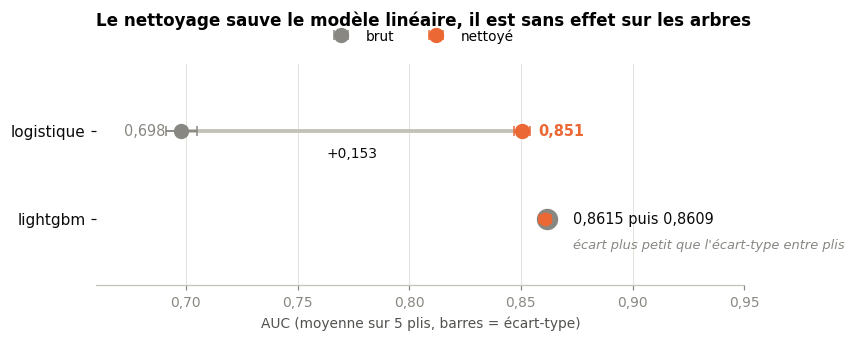

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ORANGE, GRIS, TRAIT = "#eb6834", "#898781", "#c3c2b7"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": "#898781", "ytick.color": "#0b0b0b", "font.size": 9,
    "grid.color": "#e1e0d9",
})

# Un graphique à points, pas des barres : l'écart utile se joue entre 0,70 et
# 0,86, or une barre impose un axe partant de zéro sous peine d'exagérer les
# écarts. Un point ne porte pas cette contrainte.
familles = ["logistique", "lightgbm"]
fig, ax = plt.subplots(figsize=(7.6, 2.6))

for rang, famille in enumerate(familles):
    brut = resultats.loc[f"{famille} / brut"]
    net = resultats.loc[f"{famille} / nettoyé"]
    separes = abs(net["AUC (CV)"] - brut["AUC (CV)"]) > 3 * brut["écart-type"]

    ax.plot([brut["AUC (CV)"], net["AUC (CV)"]], [rang, rang],
            color=TRAIT, lw=2.5, zorder=1, solid_capstyle="round")
    # Le point brut est tracé plus large : quand les deux se confondent, il
    # reste visible en couronne autour du point nettoyé.
    ax.errorbar(brut["AUC (CV)"], rang, xerr=brut["écart-type"], fmt="o",
                ms=13 if not separes else 9, color=GRIS, ecolor=GRIS,
                elinewidth=1.2, capsize=3, zorder=2, label="brut" if rang == 0 else None)
    ax.errorbar(net["AUC (CV)"], rang, xerr=net["écart-type"], fmt="o",
                ms=8 if not separes else 9, color=ORANGE, ecolor=ORANGE,
                elinewidth=1.2, capsize=3, zorder=3, label="nettoyé" if rang == 0 else None)

    if separes:
        ax.text(brut["AUC (CV)"] - 0.007, rang, f"{brut['AUC (CV)']:.3f}".replace(".", ","),
                ha="right", va="center", fontsize=9.5, color=GRIS)
        ax.text(net["AUC (CV)"] + 0.007, rang, f"{net['AUC (CV)']:.3f}".replace(".", ","),
                ha="left", va="center", fontsize=9.5, color=ORANGE, fontweight="bold")
        ax.text((brut["AUC (CV)"] + net["AUC (CV)"]) / 2, rang + 0.30,
                f"+{net['AUC (CV)'] - brut['AUC (CV)']:.3f}".replace(".", ","),
                ha="center", fontsize=9, color="#0b0b0b")
    else:
        # Les deux points se confondent : quatre décimales pour les distinguer,
        # et on explique pourquoi l'écart ne veut rien dire.
        x = max(brut["AUC (CV)"], net["AUC (CV)"]) + 0.012
        ax.text(x, rang, f"{brut['AUC (CV)']:.4f} puis {net['AUC (CV)']:.4f}".replace(".", ","),
                ha="left", va="center", fontsize=9.5, color="#0b0b0b")
        ax.text(x, rang + 0.30, "écart plus petit que l'écart-type entre plis",
                ha="left", va="center", fontsize=8.5, color=GRIS, style="italic")

ax.set_yticks(range(len(familles)), familles, fontsize=10)
ax.set_ylim(-0.75, len(familles) - 0.25)
ax.set_xlim(0.66, 0.95)
ax.set_xlabel("AUC (moyenne sur 5 plis, barres = écart-type)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}".replace(".", ",")))
ax.invert_yaxis()
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=2)
ax.set_title("Le nettoyage sauve le modèle linéaire, il est sans effet sur les arbres",
             pad=26)
fig.savefig("../reports/figures/05_effet_nettoyage.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

Deux lectures opposées, et les deux sont instructives.

**Pour la régression logistique, le nettoyage fait tout** : de 0,698 à 0,851
d'AUC. Le modèle passe de médiocre à correct. L'écart dépasse largement
l'écart-type entre plis, il n'y a donc aucun doute sur sa réalité.

**Pour LightGBM, il n'apporte rien** : 0,8609 contre 0,8615, un écart de
0,0006 quand l'écart-type entre plis vaut 0,0028. Autrement dit, la différence
est cinq fois plus petite que le bruit de mesure — conclure à une dégradation
serait aussi faux que conclure à une amélioration.

Ce n'est pas un échec de notre travail, c'est la nature des arbres de décision.
Un arbre ne compare que des seuils : une valeur à 50 708 part dans une feuille
isolée sans déformer les autres découpes, et LightGBM identifie de lui-même que
98 forme un groupe distinct. Il refait donc, tout seul, ce que nous avons codé
à la main.

**Faut-il pour autant jeter le nettoyage ?** Non, et pour des raisons qui n'ont
rien à voir avec le score :

- il rend viable un modèle linéaire, seule référence réellement interprétable
  quand il faudra justifier une décision de refus à un client ou à un
  régulateur ;
- il produit des indicatrices explicites, exploitables ensuite en analyse ;
- il rend le pipeline indépendant de la tolérance d'un algorithme aux valeurs
  aberrantes — si le modèle change, la préparation tient toujours.

En revanche, la leçon mérite d'être retenue telle quelle : **le nettoyage n'est
pas une vertu en soi, son utilité dépend de l'algorithme**. Sur un projet où
seul comptait le score d'un modèle à base d'arbres, ces journées de préparation
auraient été du temps perdu.

## 5. Quelle correction produit l'effet ?

Le gain de 15 points sur la régression logistique vient-il du traitement des
codes de saisie, ou de l'écrêtage des valeurs aberrantes ? On isole chaque
correction.

In [8]:
from sklearn.preprocessing import FunctionTransformer

from src.preparation import COMPTEURS_INCIDENTS


def masquer_codes(d):
    d = d.copy()
    d[COMPTEURS_INCIDENTS] = d[COMPTEURS_INCIDENTS].mask(d[COMPTEURS_INCIDENTS] >= 90)
    return d


def ecreter_utilisation(d):
    d = d.copy()
    colonne = "RevolvingUtilizationOfUnsecuredLines"
    d[colonne] = d[colonne].clip(upper=2.0)
    return d


def les_deux(d):
    return ecreter_utilisation(masquer_codes(d))


def logistique_avec(preparation=None) -> Pipeline:
    etapes = [] if preparation is None else [("preparation", preparation)]
    return Pipeline(etapes + [
        ("imputation", SimpleImputer(strategy="median", add_indicator=True)),
        ("normalisation", StandardScaler()),
        ("modele", LogisticRegression(max_iter=2000)),
    ])


variantes = {
    "aucune correction": logistique_avec(),
    "codes 96/98 seuls": logistique_avec(FunctionTransformer(masquer_codes)),
    "écrêtage seul": logistique_avec(FunctionTransformer(ecreter_utilisation)),
    "les deux": logistique_avec(FunctionTransformer(les_deux)),
    "nettoyage complet": logistique_avec(NettoyageCredit()),
}

ablation = []
for nom, chaine in variantes.items():
    scores = cross_val_score(chaine, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    ablation.append({"variante": nom, "AUC": scores.mean(), "écart-type": scores.std()})
    print(f"{nom:<20} terminé")

ablation = pd.DataFrame(ablation).set_index("variante")
ablation.round(4)

aucune correction    terminé


codes 96/98 seuls    terminé


écrêtage seul        terminé


les deux             terminé


nettoyage complet    terminé


,AUC,écart-type
variante,,
aucune correction,0.6980,0.0070
codes 96/98 seuls,0.8129,0.0036
écrêtage seul,0.8038,0.0022
les deux,0.8511,0.0036
nettoyage complet,0.8506,0.0036


Les deux corrections pèsent à peu près autant, et elles se complètent : chacune
prise seule gagne une dizaine de points, les deux ensemble en gagnent quinze.

Elles corrigent en effet deux pathologies distinctes du même modèle. Les codes
96/98 injectent une valeur fausse dans une variable très prédictive, ce qui
inverse partiellement la relation apprise. L'écrêtage, lui, ne change rien à la
relation mais rétablit la **normalisation** : `StandardScaler` calcule un
écart-type sur une colonne dont le maximum vaut 50 708, si bien que toutes les
valeurs normales se retrouvent tassées près de zéro et que la variable perd
presque tout son pouvoir discriminant.

Le traitement de `DebtRatio` et les indicatrices, eux, n'apportent rien de
mesurable ici (0,8506 contre 0,8511, sous le seuil de bruit). On les conserve
tout de même : ils documentent une réalité des données et resteront utiles
pour l'interprétation, mais il faut être lucide sur le fait qu'ils ne
contribuent pas au score.

## 6. Figer le jeu préparé

On enregistre les données nettoyées pour que la modélisation reparte d'une base
identique sans réexécuter ce notebook. Le nettoyage est ajusté sur
l'entraînement, puis **appliqué** à la validation — jamais réajusté.

In [9]:
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

nettoyage = NettoyageCredit().fit(X_train)

for nom, (Xp, yp) in {
    "train": (X_train, y_train),
    "val": (X_val, y_val),
}.items():
    jeu = nettoyage.transform(Xp)
    jeu["SeriousDlqin2yrs"] = yp
    jeu.to_parquet(PROCESSED / f"{nom}.parquet")
    print(f"{nom:<6} -> {jeu.shape[0]:>6,} lignes x {jeu.shape[1]} colonnes".replace(",", " "))

train  -> 105 000 lignes x 14 colonnes


val    -> 45 000 lignes x 14 colonnes
